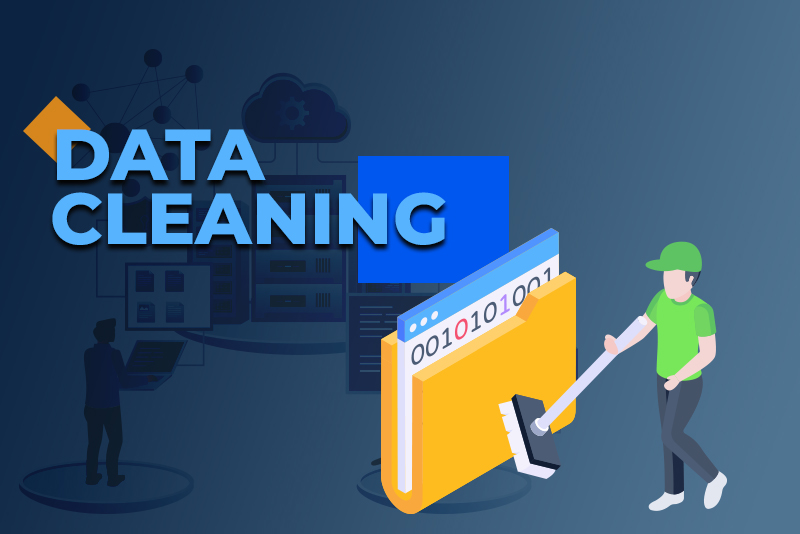

# 02. Data Cleaning & Data Preparation Report

## Problem Statement

The Data Quality Assessment identified several issues in the Meghana Foods Branch Performance Dataset, including missing values, duplicate records, invalid ratings, invalid delivery times, and inconsistent data quality.

If these issues are not corrected, they can negatively impact exploratory analysis, machine learning model performance, forecasting accuracy, and business decision-making.

Therefore, an automated data cleaning process is required to transform raw business data into a reliable and analysis-ready dataset.

---

## Business Objective

The objective of this notebook is to automatically identify and resolve data quality issues without manual intervention.

The cleaning process aims to:

• Remove duplicate records

• Fix missing business metrics

• Correct invalid customer ratings

• Correct invalid delivery times

• Standardize branch information

• Improve data consistency

• Prepare data for EDA and Machine Learning

---

## Project Lifecycle Position

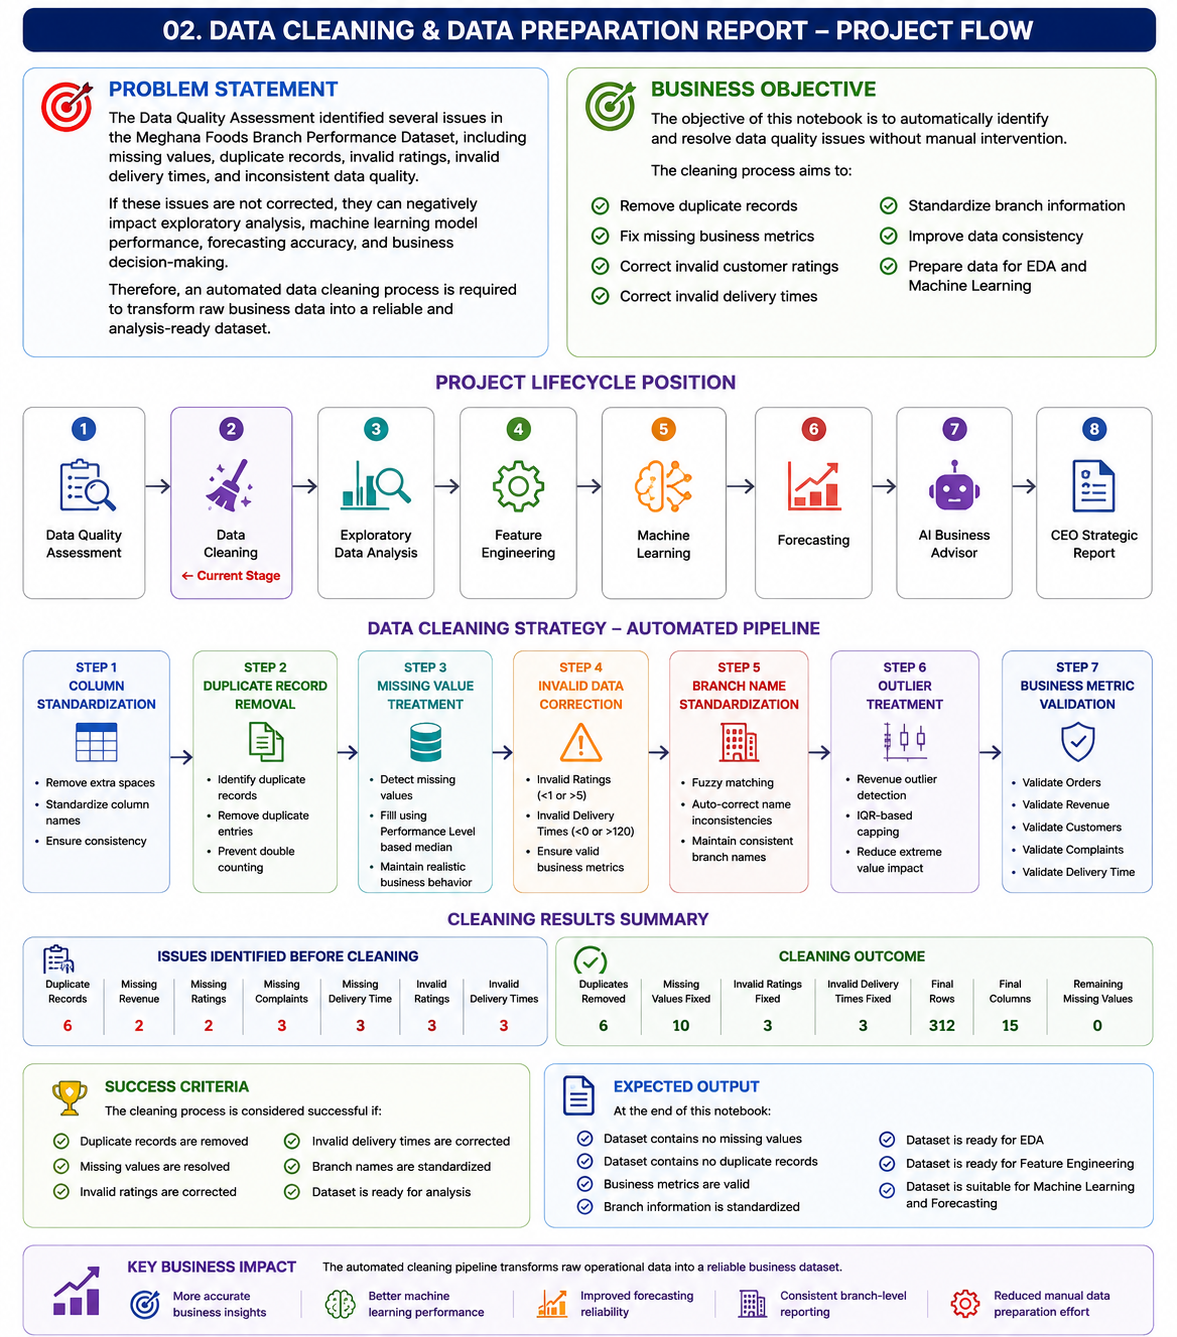

Current Stage:

```text
Data Cleaning
```

Workflow:

```text
Data Quality Assessment ✅

Data Cleaning ← Current Stage

Exploratory Data Analysis

Feature Engineering

Machine Learning

Forecasting

AI Business Advisor

CEO Strategic Report
```

---

## Data Cleaning Strategy

The cleaning process follows an automated pipeline designed to handle common real-world business data issues.

### Step 1: Column Standardization

Performed:

• Remove unnecessary spaces

• Standardize column naming conventions

Purpose:

Ensure consistency across the dataset.

---

### Step 2: Duplicate Record Removal

Performed:

• Identify duplicate records

• Remove duplicate entries

Purpose:

Prevent double-counting of revenue, orders, customers, and complaints.

---

### Step 3: Missing Value Treatment

Performed:

• Detect missing values

• Fill missing business metrics using Performance Level based median values

Purpose:

Maintain realistic business behavior while minimizing data loss.

---

### Step 4: Invalid Data Correction

Performed:

• Invalid Ratings (<1 or >5)

• Invalid Delivery Times (<0 or >120)

Purpose:

Ensure business metrics remain within realistic operational limits.

---

### Step 5: Branch Name Standardization

Performed:

• Fuzzy matching

• Automatic correction of branch naming inconsistencies

Examples:

```text
Marathalli
Marathahalli
Marathhalli
```

↓

```text
Marathahalli
```

Purpose:

Maintain consistency during analysis and aggregation.

---

### Step 6: Outlier Treatment

Performed:

• Revenue outlier detection

• IQR-based revenue capping

Purpose:

Reduce the impact of extreme values on machine learning models.

---

### Step 7: Business Metric Validation

Performed:

Validate:

• Orders

• Revenue

• Customers

• Complaints

• Delivery Time

Purpose:

Ensure business values remain logical and realistic.

---

# Cleaning Results

### Issues Identified Before Cleaning

| Issue                  | Count |
| ---------------------- | ----: |
| Duplicate Records      |     6 |
| Missing Revenue        |     2 |
| Missing Ratings        |     2 |
| Missing Complaints     |     3 |
| Missing Delivery Time  |     3 |
| Invalid Ratings        |     3 |
| Invalid Delivery Times |     3 |

---

### Cleaning Outcome

| Metric                       | Result |
| ---------------------------- | -----: |
| Duplicates Removed           |      6 |
| Missing Values Fixed         |     10 |
| Invalid Ratings Fixed        |      3 |
| Invalid Delivery Times Fixed |      3 |
| Final Rows                   |    312 |
| Final Columns                |     15 |
| Remaining Missing Values     |      0 |

---

# Success Criteria

The cleaning process is considered successful if:

✅ Duplicate records are removed

✅ Missing values are resolved

✅ Invalid ratings are corrected

✅ Invalid delivery times are corrected

✅ Branch names are standardized

✅ Dataset is ready for analysis

---

# Expected Output

At the end of this notebook:

• Dataset contains no missing values

• Dataset contains no duplicate records

• Business metrics are valid

• Branch information is standardized

• Dataset is ready for EDA

• Dataset is ready for Feature Engineering

• Dataset is suitable for Machine Learning and Forecasting

---

# Key Business Impact

The automated cleaning pipeline transforms raw operational data into a reliable business dataset.

Benefits:

• More accurate business insights

• Better machine learning performance

• Improved forecasting reliability

• Consistent branch-level reporting

• Reduced manual data preparation effort

---

After this markdown, your notebook flow should be:

```text
1. Import Libraries

2. Load Dataset

3. Before Cleaning Report

4. Automated Cleaning Function

5. Execute Cleaning

6. Before vs After Comparison

7. Cleaning Summary

8. Save Clean Dataset
```

This is strong enough to show judges that you built an **automated enterprise-grade cleaning pipeline**, not just a few Pandas commands.

After you paste this into the notebook, I'll generate the matching **Data Cleaning Project Flowchart image** in the same style as the Data Quality Assessment diagram. 🚀


# Lets Start the Data Cleaning here 

# Step 1: Import Libraries 

In [43]:
import pandas as pd
import numpy as np

# Step 2: Load Raw Dataset

In [44]:
df=pd.read_excel(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\Data\Meghana_food_branch_raw_data.xlsx")
df.head(5)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason
0,K_01,Koramangala,South,2024-01,14788,6122232.0,4.6,11733,8447,3286,42.0,22.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
1,K_02,Koramangala,South,2024-02,14919,5505111.0,4.7,11248,7761,3487,56.0,22.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
2,K_03,Koramangala,South,2024-03,13215,4770615.0,4.8,9529,6575,2954,67.0,21.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
3,K_04,Koramangala,South,2024-04,14904,5946696.0,4.6,11604,8238,3366,76.0,25.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
4,K_05,Koramangala,South,2024-05,12189,4912167.0,4.5,9686,7167,2519,85.0,NaN,High,Healthy,"Authentic taste, flagship outlet, huge footfall"


In [29]:
# Installing : rapidfuzz -> To auto clean branch names dynamically 
!pip install rapidfuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 9.2 MB/s  0:00:00


# Step 3 : Data Cleaning 

In [39]:
from rapidfuzz import process
import numpy as np
import pandas as pd

valid_branches = [
    "Koramangala", "Jayanagar", "Indiranagar", "Residency Road",
    "Marathahalli", "Singasandra", "Sarjapur Road", "Sahakar Nagar",
    "Kanakapura Road", "Electronic City", "Rajarajeshwari Nagar",
    "Mahadevapura", "Kalyan Nagar"
]

def standardize_branch_name(branch_name):
    if pd.isna(branch_name):
        return branch_name

    branch_name = str(branch_name).strip()
    best_match, score, _ = process.extractOne(branch_name, valid_branches)

    if score >= 75:
        return best_match
    return branch_name


def get_cleaning_report(df):
    return {
        "Duplicates": int(df.duplicated().sum()),
        "Missing Revenue": int(df["Revenue"].isnull().sum()),
        "Missing Rating": int(df["Avg_Rating"].isnull().sum()),
        "Missing Complaints": int(df["Complaints"].isnull().sum()),
        "Missing Delivery Time": int(df["Delivery_Time_Min"].isnull().sum()),
        "Invalid Ratings": int(((df["Avg_Rating"] < 1) | (df["Avg_Rating"] > 5)).sum()),
        "Invalid Delivery Times": int(((df["Delivery_Time_Min"] < 0) | (df["Delivery_Time_Min"] > 120)).sum())
    }


def clean_data(df):
    cleaned_df = df.copy()

    print("Starting automatic data cleaning...")

    # Standardize column names
    cleaned_df.columns = cleaned_df.columns.str.strip().str.replace(" ", "_")

    # Before report
    before_report = get_cleaning_report(cleaned_df)

    # Remove duplicates
    cleaned_df = cleaned_df.drop_duplicates()

    # Strip text columns
    text_columns = cleaned_df.select_dtypes(include="object").columns
    for col in text_columns:
        cleaned_df[col] = cleaned_df[col].astype(str).str.strip()

    # Standardize branch names using fuzzy matching
    cleaned_df["Branch_Name"] = cleaned_df["Branch_Name"].apply(standardize_branch_name)

    # Convert Month
    cleaned_df["Month"] = pd.to_datetime(cleaned_df["Month"], errors="coerce")

    # Convert numeric columns
    numeric_columns = [
        "Orders", "Revenue", "Avg_Rating", "Customer_Count",
        "Repeat_Customers", "New_Customers", "Complaints", "Delivery_Time_Min"
    ]

    for col in numeric_columns:
        cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors="coerce")

    # Invalid ratings -> NaN
    cleaned_df.loc[
        (cleaned_df["Avg_Rating"] < 1) | (cleaned_df["Avg_Rating"] > 5),
        "Avg_Rating"
    ] = np.nan

    # Invalid delivery time -> NaN
    cleaned_df.loc[
        (cleaned_df["Delivery_Time_Min"] < 0) | (cleaned_df["Delivery_Time_Min"] > 120),
        "Delivery_Time_Min"
    ] = np.nan

    # Negative business values -> NaN
    positive_columns = [
        "Orders", "Revenue", "Customer_Count",
        "Repeat_Customers", "New_Customers", "Complaints"
    ]

    for col in positive_columns:
        cleaned_df.loc[cleaned_df[col] < 0, col] = np.nan

    # Fill missing values by Performance_Level median
    for col in numeric_columns:
        cleaned_df[col] = cleaned_df.groupby("Performance_Level")[col].transform(
            lambda x: x.fillna(x.median())
        )
        cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())

    # Revenue outlier capping using IQR
    Q1 = cleaned_df["Revenue"].quantile(0.25)
    Q3 = cleaned_df["Revenue"].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    cleaned_df["Revenue"] = cleaned_df["Revenue"].clip(lower_limit, upper_limit)

    # Fix customer split if inconsistent
    cleaned_df["Customer_Count"] = cleaned_df["Customer_Count"].round()

    invalid_customer_split = (
        cleaned_df["Repeat_Customers"] + cleaned_df["New_Customers"]
    ) != cleaned_df["Customer_Count"]

    cleaned_df.loc[invalid_customer_split, "Repeat_Customers"] = (
        cleaned_df.loc[invalid_customer_split, "Customer_Count"] * 0.65
    )

    cleaned_df.loc[invalid_customer_split, "New_Customers"] = (
        cleaned_df.loc[invalid_customer_split, "Customer_Count"] -
        cleaned_df.loc[invalid_customer_split, "Repeat_Customers"]
    )

    # Final data types
    integer_columns = [
        "Orders", "Revenue", "Customer_Count", "Repeat_Customers",
        "New_Customers", "Complaints", "Delivery_Time_Min"
    ]

    for col in integer_columns:
        cleaned_df[col] = cleaned_df[col].round().astype(int)

    cleaned_df["Avg_Rating"] = cleaned_df["Avg_Rating"].round(1)

    # After report
    after_report = get_cleaning_report(cleaned_df)

    # Before vs after table
    comparison_df = pd.DataFrame({
        "Issue": before_report.keys(),
        "Before_Cleaning": before_report.values(),
        "After_Cleaning": after_report.values()
    })

    comparison_df["Status"] = np.where(
        comparison_df["After_Cleaning"] == 0,
        "✅ Fixed",
        "⚠️ Review Required"
    )

    cleaning_summary = {
        "Duplicates Removed": before_report["Duplicates"],
        "Missing Values Fixed": (
            before_report["Missing Revenue"] +
            before_report["Missing Rating"] +
            before_report["Missing Complaints"] +
            before_report["Missing Delivery Time"]
        ),
        "Invalid Ratings Fixed": before_report["Invalid Ratings"],
        "Invalid Delivery Times Fixed": before_report["Invalid Delivery Times"],
        "Final Rows": cleaned_df.shape[0],
        "Final Columns": cleaned_df.shape[1],
        "Missing Values After Cleaning": int(cleaned_df.isnull().sum().sum())
    }

    print("Automatic data cleaning completed.")

    return cleaned_df, comparison_df, cleaning_summary

In [45]:
cleaned_df, comparison_df, cleaning_summary = clean_data(df)

comparison_df

Starting automatic data cleaning...
Automatic data cleaning completed.


,Issue,Before_Cleaning,After_Cleaning,Status
0,Duplicates,6,0,✅ Fixed
1,Missing Revenue,2,0,✅ Fixed
2,Missing Rating,2,0,✅ Fixed
3,Missing Complaints,3,0,✅ Fixed
4,Missing Delivery Time,3,0,✅ Fixed
5,Invalid Ratings,3,0,✅ Fixed
6,Invalid Delivery Times,3,0,✅ Fixed


In [46]:
cleaning_summary

{'Duplicates Removed': 6,
 'Missing Values Fixed': 10,
 'Invalid Ratings Fixed': 3,
 'Invalid Delivery Times Fixed': 3,
 'Final Rows': 312,
 'Final Columns': 15,
 'Missing Values After Cleaning': 0}

In [42]:
cleaned_df.to_csv("Meghana_Branch_Performance_Cleaned.csv", index=False)